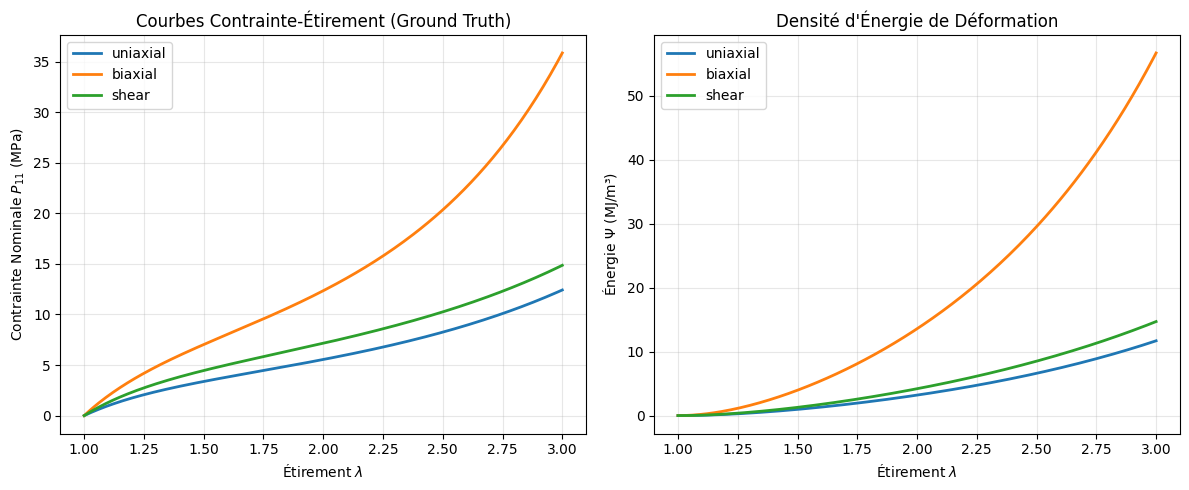

Paramètres utilisés : h1=1.0, h2=0.5, h3=0.1


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda")


class GornetDesmoratMaterial:
    def __init__(self, h1, h2, h3):
        self.h1 = h1
        self.h2 = h2
        self.h3 = h3

    def compute_energy(self, F):
        """
        Calcule l'énergie potentielle Psi à partir du gradient de transformation F.
        F est de forme (Batch_Size, 3, 3)
        """

        C = torch.bmm(F.transpose(1, 2), F)

        I1 = C[:, 0, 0] + C[:, 1, 1] + C[:, 2, 2]

        C2 = torch.bmm(C, C)
        tr_C2 = C2[:, 0, 0] + C2[:, 1, 1] + C2[:, 2, 2]
        I2 = 0.5 * (I1**2 - tr_C2)

        term1 = torch.exp(self.h3 * (I1 - 3.0)) - 1.0
        W1 = (self.h1 / self.h3) * term1

        W2 = 6.0 * self.h2 * (torch.sqrt(I2 + 1e-8) - np.sqrt(3.0))

        psi = W1 + W2
        return psi, I1, I2

    def compute_P_ground_truth(self, F):
        """
        Calcule le tenseur P exact (Vérité Terrain) en gérant l'incompressibilité.
        On utilise sigma_33 = 0 pour trouver la pression p.
        """
        F = F.clone().detach().requires_grad_(True)

        psi, _, _ = self.compute_energy(F)

        grads = torch.autograd.grad(psi.sum(), F, create_graph=False)[0]

        P_temp = grads

        sigma_temp = torch.bmm(P_temp, F.transpose(1, 2))

        p = sigma_temp[:, 2, 2].view(-1, 1, 1)

        F_inv = torch.linalg.inv(F)
        F_inv_T = F_inv.transpose(1, 2)

        P_truth = P_temp - p * F_inv_T

        return P_truth.detach(), psi.detach()

def generate_deformation_gradient(lambdas, case='uniaxial'):
    """
    Génère les tenseurs F pour différents cas de charge incompressibles.
    lambdas : vecteur des étirements principaux (lambda_1)
    """
    batch_size = len(lambdas)
    F = torch.zeros((batch_size, 3, 3))

    if case == 'uniaxial':
        l1 = lambdas
        l2 = 1.0 / torch.sqrt(l1)
        l3 = l2

    elif case == 'biaxial':
        l1 = lambdas
        l2 = lambdas
        l3 = 1.0 / (l1**2)

    elif case == 'shear':
        l1 = lambdas
        l2 = torch.ones_like(lambdas)
        l3 = 1.0 / l1

    F[:, 0, 0] = l1
    F[:, 1, 1] = l2
    F[:, 2, 2] = l3

    return F

h1=1.0
h2=0.5
h3=0.1

material = GornetDesmoratMaterial(h1, h2, h3)

lambdas = torch.linspace(1.0, 3.0, 200)

cases = ['uniaxial', 'biaxial', 'shear']
data = {}

for case in cases:
    F = generate_deformation_gradient(lambdas, case=case)
    P_true, psi_true = material.compute_P_ground_truth(F)

    P11 = P_true[:, 0, 0]
    data[case] = {'lambda': lambdas, 'P11': P11, 'psi': psi_true}

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for case in cases:
    plt.plot(data[case]['lambda'], data[case]['P11'], linewidth=2, label=f'{case}')
plt.title("Courbes Contrainte-Étirement (Ground Truth)")
plt.xlabel(r"Étirement $\lambda$")
plt.ylabel(r"Contrainte Nominale $P_{11}$ (MPa)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for case in cases:
    plt.plot(data[case]['lambda'], data[case]['psi'], linewidth=2, label=f'{case}')
plt.title("Densité d'Énergie de Déformation")
plt.xlabel(r"Étirement $\lambda$")
plt.ylabel(r"Énergie $\Psi$ (MJ/m³)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Paramètres utilisés : h1={h1}, h2={h2}, h3={h3}")

Début de l'entraînement de la Baseline FCN...
Epoch 0/200 | Loss: 36.419297
Epoch 20/200 | Loss: 0.041626
Epoch 40/200 | Loss: 0.007215
Epoch 60/200 | Loss: 0.001511
Epoch 80/200 | Loss: 0.000965
Epoch 100/200 | Loss: 0.000501
Epoch 120/200 | Loss: 0.000596
Epoch 140/200 | Loss: 0.000221
Epoch 160/200 | Loss: 0.000133
Epoch 180/200 | Loss: 0.000128


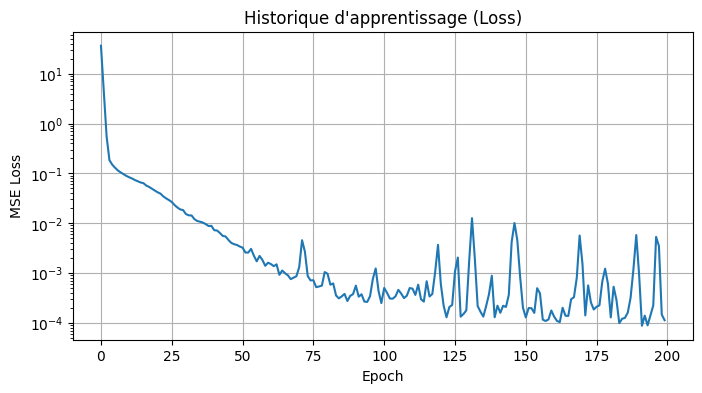

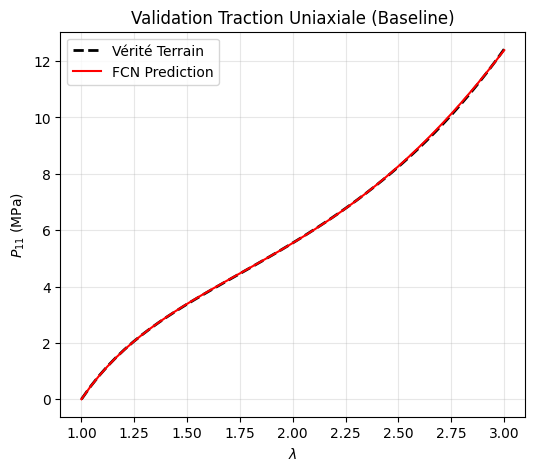

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


def create_dataset(material, n_points=1000):
    """
    Génère un dataset mixte (Uniaxial, Biaxial, Shear)
    """
    lambdas = torch.rand(n_points) * 2.0 + 1.0  # [1.0, 3.0]

    n_per_case = n_points // 3
    l_uni = lambdas[:n_per_case]
    l_bi = lambdas[n_per_case:2*n_per_case]
    l_shear = lambdas[2*n_per_case:]

    F_uni = generate_deformation_gradient(l_uni, 'uniaxial')
    F_bi = generate_deformation_gradient(l_bi, 'biaxial')
    F_shear = generate_deformation_gradient(l_shear, 'shear')

    F_data = torch.cat([F_uni, F_bi, F_shear], dim=0)

    P_truth, psi_truth = material.compute_P_ground_truth(F_data)

    C = torch.bmm(F_data.transpose(1, 2), F_data)
    I1 = C[:, 0, 0] + C[:, 1, 1] + C[:, 2, 2]

    C2 = torch.bmm(C, C)
    tr_C2 = C2[:, 0, 0] + C2[:, 1, 1] + C2[:, 2, 2]
    I2 = 0.5 * (I1**2 - tr_C2)

    inputs = torch.stack([I1, I2], dim=1)

    return inputs, F_data, P_truth, psi_truth

torch.manual_seed(42)
inputs, F_train, P_train, psi_train = create_dataset(material, n_points=1500)

class Normalizer:
    def __init__(self, data):
        self.mean = data.mean(dim=0)
        self.std = data.std(dim=0)

    def normalize(self, x):
        return (x - self.mean) / (self.std + 1e-8)

    def denormalize(self, x):
        return x * (self.std + 1e-8) + self.mean

input_normalizer = Normalizer(inputs)
X_train_norm = input_normalizer.normalize(inputs)

dataset = TensorDataset(X_train_norm, F_train, P_train, psi_train)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

class BaselineFCN(nn.Module):
    def __init__(self):
        super().__init__()
        # Architecture : 2 entrées -> Hidden -> 1 sortie (Psi)
        # Activation Softplus
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Softplus(),
            nn.Linear(64, 64),
            nn.Softplus(),
            nn.Linear(64, 64),
            nn.Softplus(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

def predict_stress_from_model(model, inputs_norm, F_batch):
    """
    Calcule P_pred en dérivant le modèle par rapport à F.
    Gère l'incompressibilité via sigma_33 = 0.
    """
    F_batch.requires_grad_(True)

    C = torch.bmm(F_batch.transpose(1, 2), F_batch)
    I1 = C[:, 0, 0] + C[:, 1, 1] + C[:, 2, 2]
    tr_C2 = (torch.bmm(C, C))[:, 0, 0] + (torch.bmm(C, C))[:, 1, 1] + (torch.bmm(C, C))[:, 2, 2]
    I2 = 0.5 * (I1**2 - tr_C2)

    inp = torch.stack([I1, I2], dim=1)
    inp_norm = input_normalizer.normalize(inp)
    psi_pred = model(inp_norm)

    grads = torch.autograd.grad(psi_pred.sum(), F_batch, create_graph=True)[0]

    sigma_dev = torch.bmm(grads, F_batch.transpose(1, 2))

    p_pred = sigma_dev[:, 2, 2].view(-1, 1, 1)

    F_inv_T = torch.linalg.inv(F_batch).transpose(1, 2)
    P_pred = grads - p_pred * F_inv_T

    return P_pred, psi_pred


model = BaselineFCN()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 200
loss_history = []

print("Début entraînement Baseline FCN")

for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_F, batch_P_true, batch_psi_true in dataloader:
        optimizer.zero_grad()

        P_pred, psi_pred = predict_stress_from_model(model, batch_X, batch_F)

        loss_P = loss_fn(P_pred, batch_P_true)
        loss_psi = loss_fn(psi_pred.squeeze(), batch_psi_true)
        loss = loss_P + 0.1 * loss_psi

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    loss_history.append(epoch_loss / len(dataloader))
    if epoch % 20 == 0:
        print(f"Epoch {epoch}/{epochs} | Loss: {loss_history[-1]:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Historique d'apprentissage (Loss)")
plt.xlabel("Epoch")
plt.yscale("log")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

model.eval()


l_test = torch.linspace(1.0, 3.0, 50)
F_test = generate_deformation_gradient(l_test, 'uniaxial')
P_true_test, _ = material.compute_P_ground_truth(F_test)

P_pred_test, psi_pred_test = predict_stress_from_model(model, None, F_test)


plt.figure(figsize=(6, 5))
plt.plot(l_test.numpy(), P_true_test[:, 0, 0].detach().numpy(), 'k--', label='Vérité Terrain', linewidth=2)
plt.plot(l_test.numpy(), P_pred_test[:, 0, 0].detach().numpy(), 'r-', label='FCN Prediction')

plt.title("Validation Traction Uniaxiale (Baseline)")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$P_{11}$ (MPa)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

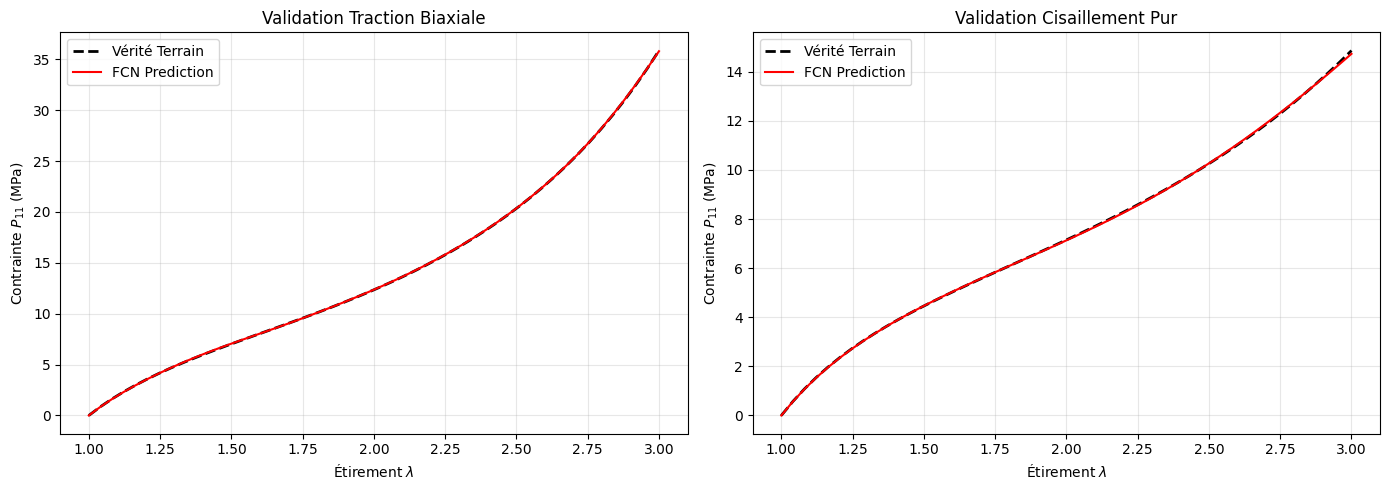

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


l_test = torch.linspace(1.0, 3.0, 50)


F_bi = generate_deformation_gradient(l_test, 'biaxial')
P_true_bi, _ = material.compute_P_ground_truth(F_bi)
P_pred_bi, _ = predict_stress_from_model(model, None, F_bi)

ax = axes[0]
ax.plot(l_test.numpy(), P_true_bi[:, 0, 0].detach().numpy(), 'k--', label='Vérité Terrain', linewidth=2)
ax.plot(l_test.numpy(), P_pred_bi[:, 0, 0].detach().numpy(), 'r-', label='FCN Prediction')
ax.set_title("Validation Traction Biaxiale")
ax.set_xlabel(r"Étirement $\lambda$")
ax.set_ylabel(r"Contrainte $P_{11}$ (MPa)")
ax.legend()
ax.grid(True, alpha=0.3)

F_sh = generate_deformation_gradient(l_test, 'shear')
P_true_sh, _ = material.compute_P_ground_truth(F_sh)
P_pred_sh, _ = predict_stress_from_model(model, None, F_sh)

ax = axes[1]
ax.plot(l_test.numpy(), P_true_sh[:, 0, 0].detach().numpy(), 'k--', label='Vérité Terrain', linewidth=2)
ax.plot(l_test.numpy(), P_pred_sh[:, 0, 0].detach().numpy(), 'r-', label='FCN Prediction')
ax.set_title("Validation Cisaillement Pur")
ax.set_xlabel(r"Étirement $\lambda$")
ax.set_ylabel(r"Contrainte $P_{11}$ (MPa)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Début de l'entraînement de l'ICNN (Poids Positifs)...
Epoch 0/250 | Loss: 16.003938
Epoch 50/250 | Loss: 0.174480
Epoch 100/250 | Loss: 0.119117
Epoch 150/250 | Loss: 0.093341
Epoch 200/250 | Loss: 0.086609


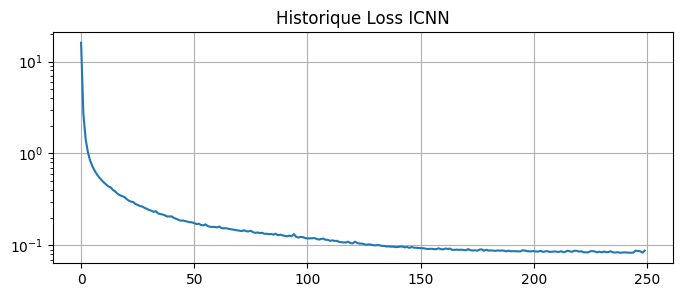

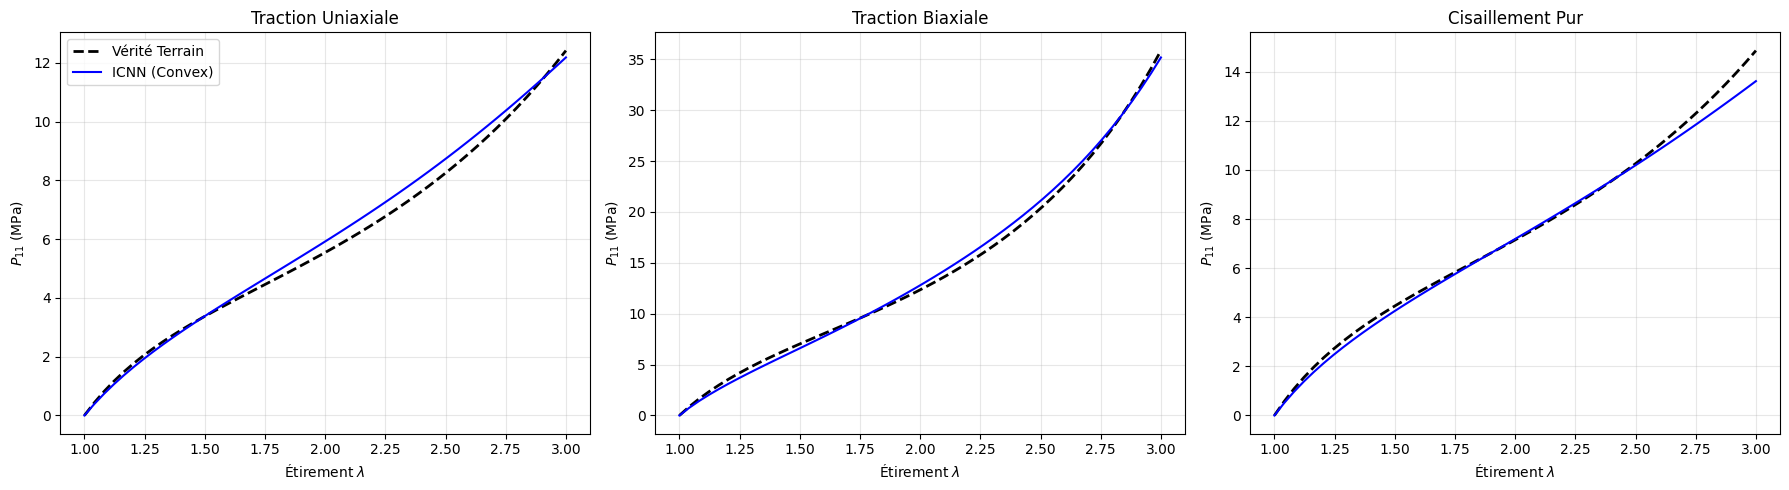

In [ ]:
class ICNN(nn.Module):
    def __init__(self, n_inputs=2, n_hidden=64, n_layers=3):
        super().__init__()
        self.n_layers = n_layers

        self.fc_start = nn.Linear(n_inputs, n_hidden)

        self.wz_layers = nn.ModuleList()
        self.wx_layers = nn.ModuleList()

        for _ in range(n_layers):
            self.wz_layers.append(nn.Linear(n_hidden, n_hidden))
            self.wx_layers.append(nn.Linear(n_inputs, n_hidden, bias=False))

        self.fc_out = nn.Linear(n_hidden, 1)

        self.act = nn.Softplus()

    def forward(self, x):
        z = self.act(self.fc_start(x))

        for wz, wx in zip(self.wz_layers, self.wx_layers):
            z = self.act(wz(z) + wx(x))
        y = self.fc_out(z)
        return y

    def enforce_convexity(self):
        for layer in self.wz_layers:
            layer.weight.data.clamp_(min=0.0)

        self.fc_out.weight.data.clamp_(min=0.0)


icnn_model = ICNN(n_inputs=2, n_hidden=64, n_layers=3)
optimizer = optim.Adam(icnn_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 250
loss_history_icnn = []

print("Début entraînement de ICNN")

for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_F, batch_P_true, batch_psi_true in dataloader:
        optimizer.zero_grad()

        P_pred, psi_pred = predict_stress_from_model(icnn_model, batch_X, batch_F)

        loss_P = loss_fn(P_pred, batch_P_true)
        loss_psi = loss_fn(psi_pred.squeeze(), batch_psi_true)

        loss = loss_P + 0.1 * loss_psi

        loss.backward()
        optimizer.step()
        icnn_model.enforce_convexity()
        epoch_loss += loss.item()

    loss_history_icnn.append(epoch_loss / len(dataloader))

    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{epochs} | Loss: {loss_history_icnn[-1]:.6f}")


def plot_validation_results(model, model_name="Model"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    l_test = torch.linspace(1.0, 3.0, 50)

    test_cases = [
        ('uniaxial', 'Traction Uniaxiale'),
        ('biaxial', 'Traction Biaxiale'),
        ('shear', 'Cisaillement Pur')
    ]

    for i, (case_key, case_name) in enumerate(test_cases):
        F_case = generate_deformation_gradient(l_test, case_key)
        with torch.enable_grad():
            P_true, _ = material.compute_P_ground_truth(F_case)

        P_pred, _ = predict_stress_from_model(model, None, F_case)

        ax = axes[i]
        ax.plot(l_test.numpy(), P_true[:, 0, 0].detach().numpy(), 'k--', label='Vérité Terrain', linewidth=2)
        ax.plot(l_test.numpy(), P_pred[:, 0, 0].detach().numpy(), 'b-', label=f'{model_name}')

        ax.set_title(case_name)
        ax.set_xlabel(r"Étirement $\lambda$")
        ax.set_ylabel(r"$P_{11}$ (MPa)")
        if i == 0: ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 3))
plt.plot(loss_history_icnn)
plt.title("Historique Loss ICNN")
plt.yscale("log")
plt.grid()
plt.show()

plot_validation_results(icnn_model, model_name="ICNN (Convex)")

Entraînement ICNN Augmenté (Features Physiques)...
Epoch 0 | Loss: 21.045258
Epoch 50 | Loss: 0.083356
Epoch 100 | Loss: 0.027848
Epoch 150 | Loss: 0.008086
Epoch 200 | Loss: 0.002115


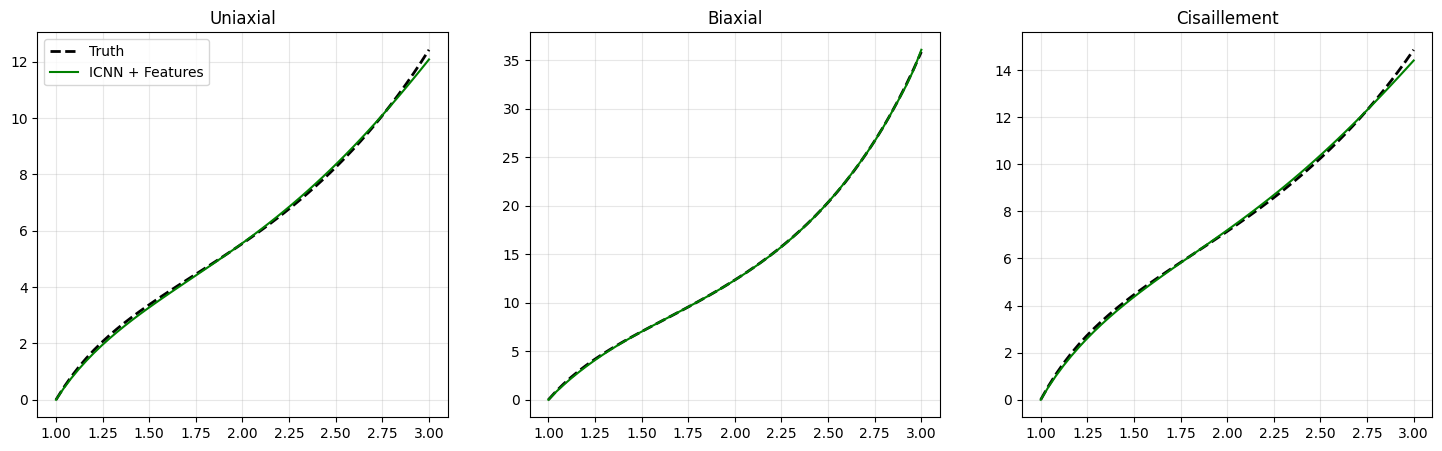

In [ ]:
class PhysicsInputLayer(nn.Module):
    def __init__(self, input_normalizer=None):
        super().__init__()
        self.normalizer = input_normalizer

    def forward(self, I1, I2):
        f1 = I1 - 3.0
        f2 = I2 - 3.0

        f3 = torch.exp(f1)
        f4 = torch.sqrt(I2 + 1e-8)
        features = torch.stack([f1, f2, f3, f4], dim=1)

        if self.normalizer:
            features = self.normalizer.normalize(features)
        return features


def prepare_augmented_features(F_data):
    C = torch.bmm(F_data.transpose(1, 2), F_data)
    I1 = C[:, 0, 0] + C[:, 1, 1] + C[:, 2, 2]
    tr_C2 = (torch.bmm(C, C))[:, 0, 0] + (torch.bmm(C, C))[:, 1, 1] + (torch.bmm(C, C))[:, 2, 2]
    I2 = 0.5 * (I1**2 - tr_C2)

    f1 = I1 - 3.0
    f2 = I2 - 3.0
    f3 = torch.exp(f1)
    f4 = torch.sqrt(I2 + 1e-8)

    raw_features = torch.stack([f1, f2, f3, f4], dim=1)
    return raw_features, I1, I2


features_train, I1_train, I2_train = prepare_augmented_features(F_train)
aug_normalizer = Normalizer(features_train)

def predict_stress_augmented(model, feature_layer, F_batch):
    F_batch.requires_grad_(True)

    C = torch.bmm(F_batch.transpose(1, 2), F_batch)
    I1 = C[:, 0, 0] + C[:, 1, 1] + C[:, 2, 2]
    tr_C2 = (torch.bmm(C, C))[:, 0, 0] + (torch.bmm(C, C))[:, 1, 1] + (torch.bmm(C, C))[:, 2, 2]
    I2 = 0.5 * (I1**2 - tr_C2)

    features = feature_layer(I1, I2)

    psi_pred = model(features)

    grads = torch.autograd.grad(psi_pred.sum(), F_batch, create_graph=True)[0]

    sigma_dev = torch.bmm(grads, F_batch.transpose(1, 2))
    p_pred = sigma_dev[:, 2, 2].view(-1, 1, 1)
    F_inv_T = torch.linalg.inv(F_batch).transpose(1, 2)
    P_pred = grads - p_pred * F_inv_T

    return P_pred, psi_pred

icnn_augmented = ICNN(n_inputs=4, n_hidden=64, n_layers=3)
feature_layer = PhysicsInputLayer(aug_normalizer)

optimizer = optim.Adam(icnn_augmented.parameters(), lr=1e-3)

print("Entraînement ICNN Augmenté (Features Physiques)...")
loss_history_aug = []

for epoch in range(250):
    epoch_loss = 0
    for batch_X, batch_F, batch_P_true, batch_psi_true in dataloader:
        optimizer.zero_grad()

        P_pred, psi_pred = predict_stress_augmented(icnn_augmented, feature_layer, batch_F)

        loss_P = loss_fn(P_pred, batch_P_true)
        loss_psi = loss_fn(psi_pred.squeeze(), batch_psi_true)

        loss = loss_P + 0.1 * loss_psi
        loss.backward()
        optimizer.step()

        icnn_augmented.enforce_convexity()
        epoch_loss += loss.item()

    loss_history_aug.append(epoch_loss / len(dataloader))
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss_history_aug[-1]:.6f}")

def plot_augmented_results():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    l_test = torch.linspace(1.0, 3.0, 50)
    test_cases = [('uniaxial', 'Uniaxial'), ('biaxial', 'Biaxial'), ('shear', 'Cisaillement')]

    for i, (case_key, case_name) in enumerate(test_cases):
        F_case = generate_deformation_gradient(l_test, case_key)
        with torch.enable_grad():
            P_true, _ = material.compute_P_ground_truth(F_case)
            P_pred, _ = predict_stress_augmented(icnn_augmented, feature_layer, F_case)

        ax = axes[i]
        ax.plot(l_test.numpy(), P_true[:, 0, 0].detach().numpy(), 'k--', label='Vérité Terrain', linewidth=2)
        ax.plot(l_test.numpy(), P_pred[:, 0, 0].detach().numpy(), 'g-', label='ICNN + Features')
        ax.set_title(case_name)
        if i==0: ax.legend()
        ax.grid(True, alpha=0.3)
    plt.show()

plot_augmented_results()

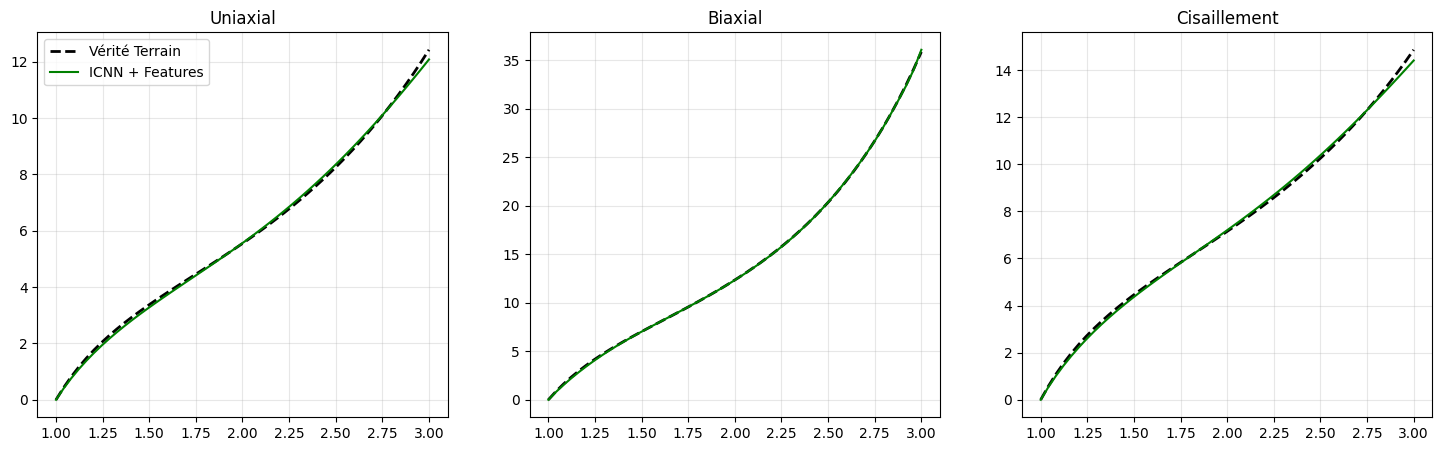

In [ ]:
def plot_augmented_results():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    l_test = torch.linspace(1.0, 3.0, 50)
    test_cases = [('uniaxial', 'Uniaxial'), ('biaxial', 'Biaxial'), ('shear', 'Cisaillement')]

    for i, (case_key, case_name) in enumerate(test_cases):
        F_case = generate_deformation_gradient(l_test, case_key)
        with torch.enable_grad():
            P_true, _ = material.compute_P_ground_truth(F_case)
            P_pred, _ = predict_stress_augmented(icnn_augmented, feature_layer, F_case)

        ax = axes[i]
        ax.plot(l_test.numpy(), P_true[:, 0, 0].detach().numpy(), 'k--', label='Vérité Terrain', linewidth=2)
        ax.plot(l_test.numpy(), P_pred[:, 0, 0].detach().numpy(), 'g-', label='ICNN + Features') # Vert pour le succès ?
        ax.set_title(case_name)
        if i==0: ax.legend()
        ax.grid(True, alpha=0.3)
    plt.show()

plot_augmented_results()